# H3 Geospatial Indexing Demo with Synthetic Spain Coordinates

This notebook focuses on **H3 geospatial indexing** using a synthetic dataset of latitude/longitude points across Spain.

The goal is to:

- Start from a simple `LATITUDE` / `LONGITUDE` dataset (10,000 points around major Spanish cities).
- Compute **H3 hexagon IDs** at different resolutions.
- Explore how H3:
  - Groups nearby points into the same hexagon.
  - Provides a hierarchical, multi-resolution geospatial index.
- Produce an enriched dataset ready for:
  - Spatial aggregations (counts per hexagon).
  - Visual exploration.
  - Feeding downstream analytics or anomaly detection models.

This notebook is intentionally focused **only on H3** (no temporal features, no external joins) so it can be used as a clean, didactic demo and as the basis for an article explaining H3 line by line.


In [3]:
!pip install h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.0 MB/s eta 0:00:00


In [11]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# H3 geospatial indexing (compatible with common versions)
try:
    from h3 import h3  # most common pattern
except ImportError:
    import h3  # fallback

# Plotting config
%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True


## 1. Load the synthetic Spain dataset

We start from a CSV file with 10,000 synthetic points around several Spanish cities.

The file is expected to have at least the following columns:

- `ID`: Unique identifier per row.
- `CITY`: City label used when generating the point (Madrid, Barcelona, etc.).
- `LATITUDE`: Latitude in decimal degrees.
- `LONGITUDE`: Longitude in decimal degrees.

You can adjust the `file_path` below depending on where you placed the CSV.


In [6]:
# Adjust this path to wherever you stored the CSV
file_path = Path("spain_h3_demo_points.csv")

df = pd.read_csv(file_path)

print(f"Rows: {len(df)}")
print(df.dtypes)
df.head()


Rows: 10000
ID             int64
CITY          object
LATITUDE     float64
LONGITUDE    float64
dtype: object


,ID,CITY,LATITUDE,LONGITUDE
0,1,Madrid,40.371730,-3.784410
1,2,Madrid,40.631801,-3.412178
2,3,Madrid,40.579999,-3.621693
3,4,Madrid,40.091603,-3.856003
4,5,Madrid,40.555630,-3.821755


## 2. Quick visual sanity check

Before introducing H3, it's useful to confirm that:

- Latitudes and longitudes look reasonable for Spain.
- Points cluster around known urban areas (Madrid, Barcelona, etc.).

We'll do a simple scatter plot in (longitude, latitude) space. This is **not** a proper map projection, but it's enough for a quick sanity check.


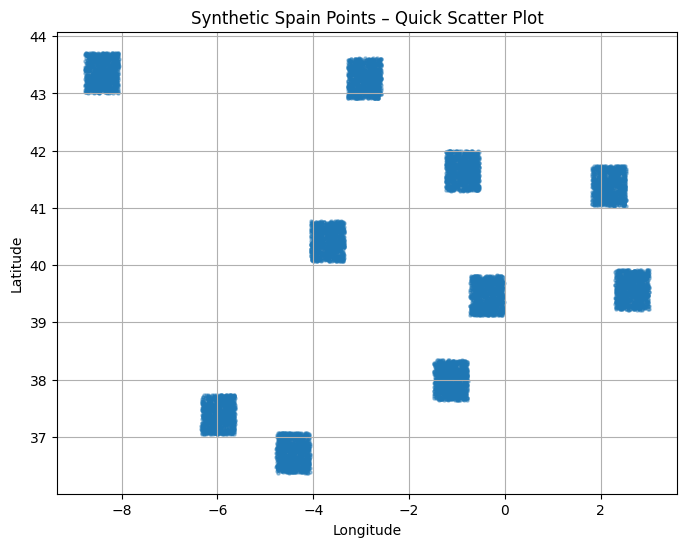

In [8]:
fig, ax = plt.subplots()

ax.scatter(
    df["LONGITUDE"],
    df["LATITUDE"],
    s=5,
    alpha=0.4,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Synthetic Spain Points – Quick Scatter Plot");



## 3. What is H3 (High-level)

**H3** is a hierarchical, hexagon-based geospatial indexing system originally developed at Uber.

Key ideas:

- The Earth is partitioned into **hexagonal cells** (plus a few pentagons).
- Each cell has a unique **H3 index** (a string encoding its position and resolution).
- **Resolution** is an integer (0–15) that controls cell size:
  - Low resolution → very large hexagons (continent/country scale).
  - High resolution → small hexagons (city/block/street scale).
- H3 is **hierarchical**:
  - A hexagon at resolution *r* contains several child hexagons at resolution *r+1*.
  - This makes it natural to aggregate or drill down across resolutions.

In this notebook, we will:

- Choose a few H3 resolutions (e.g., 5, 6, 7) suitable for a country-scale demo.
- Convert each `(LATITUDE, LONGITUDE)` pair into one or more H3 indices.
- Aggregate data *by H3 cell* to show how it clusters the points.


In [9]:
# H3 resolutions we want to explore
H3_RESOLUTIONS = [5, 6, 7]

H3_RESOLUTIONS


[5, 6, 7]

## 4. Compute H3 indices from latitude/longitude

We now:

1. Define a helper function that converts `(LATITUDE, LONGITUDE)` to an H3 index at a given resolution.
2. For each chosen resolution (e.g. 5, 6, 7), we add a new column:
   - `H3_R5`, `H3_R6`, `H3_R7`.

Notes:

- The `h3.geo_to_h3(lat, lon, res)` function returns a string representing the H3 cell.
- All points that fall into the **same H3 cell** will share the same H3 index string.


In [13]:
import h3  # por si acaso no estaba ya importado

def latlon_to_h3(lat: float, lon: float, res: int) -> str:
    """
    Convert (lat, lon) in decimal degrees to an H3 index at resolution `res`,
    trying to be compatible with different h3-python versions.
    """
    # Old / classic API
    if hasattr(h3, "geo_to_h3"):
        return h3.geo_to_h3(lat, lon, res)
    # Newer API (v4 style)
    if hasattr(h3, "latlng_to_cell"):
        return h3.latlng_to_cell(lat, lon, res)
    # Fallback: some installs use submodule h3.h3
    try:
        from h3 import h3 as h3core
        if hasattr(h3core, "geo_to_h3"):
            return h3core.geo_to_h3(lat, lon, res)
    except Exception:
        pass

    raise AttributeError(
        "Could not find a suitable H3 function for lat/lon → index. "
        f"Available attributes: {dir(h3)}"
    )


for res in H3_RESOLUTIONS:
    col_name = f"H3_R{res}"
    df[col_name] = df.apply(
        lambda row: latlon_to_h3(row["LATITUDE"], row["LONGITUDE"], res),
        axis=1
    )
    print(f"Added column: {col_name}")

df.head()


Added column: H3_R5
Added column: H3_R6
Added column: H3_R7


,ID,CITY,LATITUDE,LONGITUDE,H3_R5,H3_R6,H3_R7
0,1,Madrid,40.371730,-3.784410,85390cbbfffffff,86390cbafffffff,87390cbaaffffff
1,2,Madrid,40.631801,-3.412178,85392b7bfffffff,86392b78fffffff,87392b6a4ffffff
2,3,Madrid,40.579999,-3.621693,85390cb7fffffff,86392b4dfffffff,87390cb66ffffff
3,4,Madrid,40.091603,-3.856003,85390c03fffffff,86390c02fffffff,87390c029ffffff
4,5,Madrid,40.555630,-3.821755,85392b4bfffffff,86392b49fffffff,87392b499ffffff


## 5. How many H3 cells do we use?

Now that we have H3 indices at different resolutions, we can inspect:

- How many **distinct H3 cells** we have at each resolution.
- Intuitively:
  - Lower resolutions → fewer, larger hexagons.
  - Higher resolutions → more, smaller hexagons.

This already illustrates the **hierarchical** nature of H3: as we increase the resolution, we zoom into smaller areas and the number of cells grows.


In [14]:
for res in H3_RESOLUTIONS:
    col = f"H3_R{res}"
    nunique = df[col].nunique()
    print(f"Resolution {res}: {nunique} distinct H3 cells")


Resolution 5: 274 distinct H3 cells
Resolution 6: 1423 distinct H3 cells
Resolution 7: 6071 distinct H3 cells


## 6. Aggregate by H3 cell (resolution 6)

To make H3 more tangible, we will:

1. Pick a **working resolution** (here, `6`) that is reasonable for a **country-level** demo.
2. Group all points by the H3 index at that resolution (`H3_R6`).
3. For each H3 cell, compute:
   - `POINT_COUNT`: number of points in that hexagon.
   - `CITY_MODE`: most frequent city label within that hexagon (for interpretation).
   - `CENTER_LAT`, `CENTER_LON`: the centroid of the H3 cell.

This gives us a **hexagon-level dataset** that is perfect for:

- Heatmaps (counts per hex).
- Comparing densities of points across regions.
- Feeding downstream anomaly detection or other ML models.


In [15]:
import numpy as np
import h3  # ensure h3 is imported

# 1) Choose a working resolution
WORKING_RES = 6
h3_col = f"H3_R{WORKING_RES}"

# 2) Group by H3 cell
grouped = df.groupby(h3_col)

# Helper: safe mode (most frequent value)
def mode_or_nan(series: pd.Series):
    if series.empty:
        return np.nan
    return series.mode().iloc[0]


# Helper: H3 index -> (lat, lon) centroid (version-safe)
def h3_to_centroid(h3_index: str):
    """
    Convert an H3 index to (lat, lon) centroid, compatible with different h3-python versions.
    """
    # Old / classic API
    if hasattr(h3, "h3_to_geo"):
        return h3.h3_to_geo(h3_index)
    # Newer API (v4 style)
    if hasattr(h3, "cell_to_latlng"):
        return h3.cell_to_latlng(h3_index)
    # Fallback via submodule
    try:
        from h3 import h3 as h3core
        if hasattr(h3core, "h3_to_geo"):
            return h3core.h3_to_geo(h3_index)
    except Exception:
        pass

    raise AttributeError(
        "Could not find a suitable H3 function for index → centroid. "
        f"Available attributes in h3: {dir(h3)}"
    )


# 3) Build aggregated dataframe
agg_hex = pd.DataFrame({
    "H3_INDEX": grouped.size().index,
    "POINT_COUNT": grouped.size().values,
})

# Most frequent city per hex (just for interpretability)
agg_hex["CITY_MODE"] = grouped["CITY"].apply(mode_or_nan).values

# 4) Compute centroids for each hex
centers = agg_hex["H3_INDEX"].apply(h3_to_centroid)
agg_hex["CENTER_LAT"] = centers.apply(lambda x: x[0])
agg_hex["CENTER_LON"] = centers.apply(lambda x: x[1])

agg_hex.head()


,H3_INDEX,POINT_COUNT,CITY_MODE,CENTER_LAT,CENTER_LON
0,86184a20fffffff,3,Bilbao,43.581934,-3.289138
1,86184a22fffffff,1,Bilbao,43.627559,-3.240841
2,86184a247ffffff,5,Bilbao,43.515355,-3.181687
3,86184a24fffffff,10,Bilbao,43.459243,-3.152192
4,86184a257ffffff,4,Bilbao,43.525831,-3.259501


## 7. Visualise H3 aggregation (centroids with point counts)

We now visualise the aggregation:

- One marker per **H3 hexagon** (using its centroid).
- Marker size proportional to the `POINT_COUNT` in that hexagon.

Even though we are not drawing full hexagon polygons, this is enough to see:

- Where the dataset is denser (bigger markers).
- How H3 provides a smooth spatial aggregation over Spain.


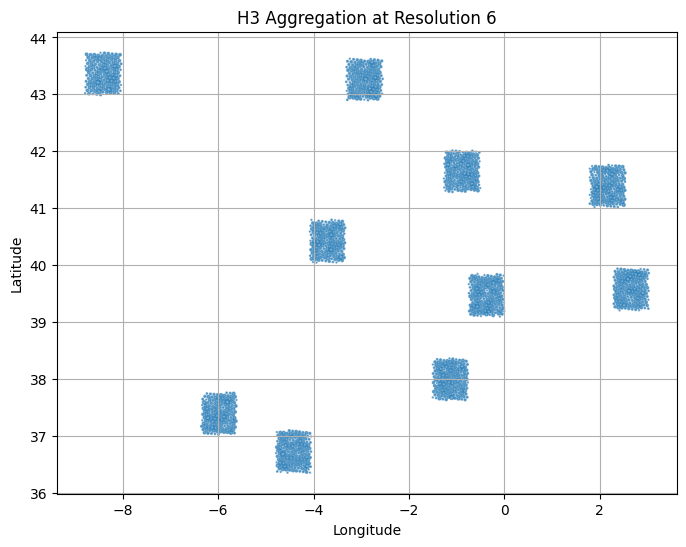

In [16]:
fig, ax = plt.subplots()

scatter = ax.scatter(
    agg_hex["CENTER_LON"],
    agg_hex["CENTER_LAT"],
    s=agg_hex["POINT_COUNT"] * 0.5,  # scale factor
    alpha=0.6,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"H3 Aggregation at Resolution {WORKING_RES}")
plt.show()


## 8. Multi-resolution H3 example for a single point

One of the most powerful aspects of H3 is its **hierarchy**.

To illustrate this:

1. Select a single point (for example, one from Madrid if available).
2. Compute its H3 index at several resolutions (e.g. 3 to 8).
3. Observe how:
   - It's always the **same geographic location**.
   - The **H3 index string** changes with resolution.
   - Each resolution corresponds to a different hexagon size.

This is exactly what allows you to "zoom in" and "zoom out" in geospatial analytics with a consistent indexing system.


In [17]:
# Pick one sample point (preferably from Madrid, if present)
if "Madrid" in df["CITY"].unique():
    sample_row = df[df["CITY"] == "Madrid"].sample(1, random_state=42).iloc[0]
else:
    sample_row = df.sample(1, random_state=42).iloc[0]

lat = sample_row["LATITUDE"]
lon = sample_row["LONGITUDE"]
city = sample_row["CITY"]

print(f"Sample point from city: {city}")
print(f"Latitude:  {lat}")
print(f"Longitude: {lon}\n")

for res in range(3, 9):  # resolutions 3–8
    h3_index = latlon_to_h3(lat, lon, res)
    print(f"Resolution {res}: {h3_index}")


Sample point from city: Madrid
Latitude:  40.384181
Longitude: -3.915142

Resolution 3: 83390cfffffffff
Resolution 4: 84390c9ffffffff
Resolution 5: 85390c87fffffff
Resolution 6: 86390c85fffffff
Resolution 7: 87390c85affffff
Resolution 8: 88390c85a3fffff


## 9. Save the H3-enriched dataset

As a final step, we persist the dataset including:

- Original columns: `ID`, `CITY`, `LATITUDE`, `LONGITUDE`.
- H3 indices at all selected resolutions: `H3_R5`, `H3_R6`, `H3_R7`.

This file can be:

- Reused in other notebooks (for example, anomaly detection or clustering).
- Loaded into Oracle APEX, OML or any other tool.
- Shared as a starting point for tutorials or articles about H3.


In [18]:
from pathlib import Path

output_path = Path("spain_h3_demo_points_enriched.csv")
df.to_csv(output_path, index=False)

print(f"✅ Enriched dataset saved to: {output_path.resolve()}")
print(df.head())


✅ Enriched dataset saved to: /home/datascience/1-Customers/Workshops/11-BTO/medium article/spain_h3_demo_points_enriched.csv
   ID    CITY   LATITUDE  LONGITUDE            H3_R5            H3_R6  \
0   1  Madrid  40.371730  -3.784410  85390cbbfffffff  86390cbafffffff   
1   2  Madrid  40.631801  -3.412178  85392b7bfffffff  86392b78fffffff   
2   3  Madrid  40.579999  -3.621693  85390cb7fffffff  86392b4dfffffff   
3   4  Madrid  40.091603  -3.856003  85390c03fffffff  86390c02fffffff   
4   5  Madrid  40.555630  -3.821755  85392b4bfffffff  86392b49fffffff   

             H3_R7  
0  87390cbaaffffff  
1  87392b6a4ffffff  
2  87390cb66ffffff  
3  87390c029ffffff  
4  87392b499ffffff  


## 10. Attach neighbourhoods (barrios) only for points inside Madrid city

In the previous steps we generated synthetic points across several Spanish
cities and computed their H3 indices.

For this last part, we want a **clean, city-level example**:

- Keep only points labelled as `CITY = "Madrid"`.
- Further restrict them to points that actually fall **inside the official
  municipality of Madrid**, using the city neighbourhood polygons.
- Attach a human-readable `BARRIO` and `DISTRITO` to each point.
- Drop any points that fall outside the municipality so that we end up with
  **no empty values** in `BARRIO` / `DISTRITO`.

We keep the H3 index (e.g. `H3_R6`) so that each point has both:

- a hexagonal H3 index, and
- a neighbourhood and district label.


In [26]:
import pandas as pd
from pathlib import Path

# Load the enriched dataset (with H3 columns)
input_path = Path("spain_h3_demo_points_enriched.csv")
df = pd.read_csv(input_path)

# Ensure numeric types
df["LATITUDE"] = df["LATITUDE"].astype(float)
df["LONGITUDE"] = df["LONGITUDE"].astype(float)

# 1) Keep only rows for the city of Madrid
df_madrid = df[df["CITY"] == "Madrid"].copy()
df_madrid.reset_index(drop=True, inplace=True)

print(f"Total points in original dataset: {len(df)}")
print(f"Points labelled as CITY='Madrid': {len(df_madrid)}")

df_madrid.head()


Total points in original dataset: 10000
Points labelled as CITY='Madrid': 1000


,ID,CITY,LATITUDE,LONGITUDE,H3_R5,H3_R6,H3_R7
0,1,Madrid,40.371730,-3.784410,85390cbbfffffff,86390cbafffffff,87390cbaaffffff
1,2,Madrid,40.631801,-3.412178,85392b7bfffffff,86392b78fffffff,87392b6a4ffffff
2,3,Madrid,40.579999,-3.621693,85390cb7fffffff,86392b4dfffffff,87390cb66ffffff
3,4,Madrid,40.091603,-3.856003,85390c03fffffff,86390c02fffffff,87390c029ffffff
4,5,Madrid,40.555630,-3.821755,85392b4bfffffff,86392b49fffffff,87392b499ffffff


In [28]:
import geopandas as gpd
from shapely.geometry import Point

# Path to the barrios shapefile from Barrios.zip
barrios_shp_path = Path("neighborhoods/BARRIOS.shp")  # adjust if needed

# 2) Load barrios polygons and ensure WGS84
gdf_barrios = gpd.read_file(barrios_shp_path)
gdf_barrios = gdf_barrios.to_crs(epsg=4326)

print(gdf_barrios.head())
print("CRS:", gdf_barrios.crs)

# 3) Build GeoDataFrame for Madrid points
gdf_points = gpd.GeoDataFrame(
    df_madrid.copy(),
    geometry=gpd.points_from_xy(df_madrid["LONGITUDE"], df_madrid["LATITUDE"]),
    crs="EPSG:4326",
)

gdf_points.head()


    Shape_Leng    Shape_Area CODDIS COD_DIS_TX  NOMDIS COD_BAR COD_DISBAR  \
0  5754.828568  1.469906e+06      1         01  Centro     011         11   
1  4275.226840  1.033724e+06      1         01  Centro     012         12   
2  3731.081359  5.918742e+05      1         01  Centro     013         13   
3  3597.421057  7.394135e+05      1         01  Centro     014         14   
4  4060.075563  9.480264e+05      1         01  Centro     015         15   

  COD_DISB NUM_BAR       NOMBRE   BARRIO_MAY    BARRIO_MT FCH_ALTA FCH_BAJA  \
0      1-1       1      Palacio      PALACIO      PALACIO     None     None   
1      1-2       2  Embajadores  EMBAJADORES  EMBAJADORES     None     None   
2      1-3       3       Cortes       CORTES       CORTES     None     None   
3      1-4       4     Justicia     JUSTICIA     JUSTICIA     None     None   
4      1-5       5  Universidad  UNIVERSIDAD  UNIVERSIDAD     None     None   

  OBSERVACIO APROBACION                                       

,ID,CITY,LATITUDE,LONGITUDE,H3_R5,H3_R6,H3_R7,geometry
0,1,Madrid,40.371730,-3.784410,85390cbbfffffff,86390cbafffffff,87390cbaaffffff,POINT (-3.78441 40.37173)
1,2,Madrid,40.631801,-3.412178,85392b7bfffffff,86392b78fffffff,87392b6a4ffffff,POINT (-3.41218 40.63180)
2,3,Madrid,40.579999,-3.621693,85390cb7fffffff,86392b4dfffffff,87390cb66ffffff,POINT (-3.62169 40.58000)
3,4,Madrid,40.091603,-3.856003,85390c03fffffff,86390c02fffffff,87390c029ffffff,POINT (-3.85600 40.09160)
4,5,Madrid,40.555630,-3.821755,85392b4bfffffff,86392b49fffffff,87392b499ffffff,POINT (-3.82176 40.55563)


In [29]:
# Columns in the barrios shapefile
COD_BAR_COL = "COD_BAR"      # barrio code
BARRIO_NAME_COL = "NOMBRE"   # barrio name
DISTRICT_NAME_COL = "NOMDIS" # district name

# Keep only what we need from the polygons layer
gdf_barrios_slim = gdf_barrios[[COD_BAR_COL, BARRIO_NAME_COL, DISTRICT_NAME_COL, "geometry"]].copy()

# 4) Spatial join: assign each point to the barrio polygon that contains it
gdf_joined = gpd.sjoin(
    gdf_points,
    gdf_barrios_slim,
    how="left",
    predicate="within",  # point within polygon
)

gdf_joined[[ "CITY", "LATITUDE", "LONGITUDE", "H3_R6", BARRIO_NAME_COL, DISTRICT_NAME_COL ]].head()


,CITY,LATITUDE,LONGITUDE,H3_R6,NOMBRE,NOMDIS
0,Madrid,40.371730,-3.784410,86390cbafffffff,Cuatro Vientos,Latina
1,Madrid,40.631801,-3.412178,86392b78fffffff,NaN,NaN
2,Madrid,40.579999,-3.621693,86392b4dfffffff,El Pardo,Fuencarral - El Pardo
3,Madrid,40.091603,-3.856003,86390c02fffffff,NaN,NaN
4,Madrid,40.555630,-3.821755,86392b49fffffff,El Pardo,Fuencarral - El Pardo


In [30]:
# 5) Keep only points that fall inside some barrio (drop NaNs)
gdf_joined = gdf_joined[gdf_joined[BARRIO_NAME_COL].notna()].copy()
gdf_joined.reset_index(drop=True, inplace=True)

print(f"Points inside Madrid municipality (with barrio): {len(gdf_joined)}")
print("Any missing BARRIO?", gdf_joined[BARRIO_NAME_COL].isna().sum())
print("Any missing DISTRITO?", gdf_joined[DISTRICT_NAME_COL].isna().sum())


Points inside Madrid municipality (with barrio): 135
Any missing BARRIO? 0
Any missing DISTRITO? 0


In [31]:
# 6) Rename barrio / district columns for clarity
gdf_joined.rename(
    columns={
        BARRIO_NAME_COL: "BARRIO",
        DISTRICT_NAME_COL: "DISTRITO"
    },
    inplace=True,
)

# Drop geometry for the final tabular dataset
df_final = pd.DataFrame(gdf_joined.drop(columns="geometry"))

df_final[["ID", "CITY", "LATITUDE", "LONGITUDE", "H3_R6", "BARRIO", "DISTRITO"]].head()


,ID,CITY,LATITUDE,LONGITUDE,H3_R6,BARRIO,DISTRITO
0,1,Madrid,40.371730,-3.784410,86390cbafffffff,Cuatro Vientos,Latina
1,3,Madrid,40.579999,-3.621693,86392b4dfffffff,El Pardo,Fuencarral - El Pardo
2,5,Madrid,40.555630,-3.821755,86392b49fffffff,El Pardo,Fuencarral - El Pardo
3,12,Madrid,40.506422,-3.711105,86390cb07ffffff,El Goloso,Fuencarral - El Pardo
4,16,Madrid,40.616468,-3.646543,86392b4dfffffff,El Pardo,Fuencarral - El Pardo


In [32]:
output_final = Path("madrid_h3_points_with_barrios.csv")
df_final.to_csv(output_final, index=False)

print(f"✅ Final Madrid dataset with H3 + barrio + distrito saved to: {output_final.resolve()}")


✅ Final Madrid dataset with H3 + barrio + distrito saved to: /home/datascience/1-Customers/Workshops/11-BTO/medium article/madrid_h3_points_with_barrios.csv


## 11. Heatmap by neighbourhood (barrios)

Now that each point in Madrid has a `BARRIO` and `DISTRITO`, we can build a
**choropleth map** at barrio level:

1. Aggregate the number of points per barrio.
2. Join that count to the official barrio polygons.
3. Colour each polygon using the point count as a simple heatmap.

This gives us a human-readable view:

- Which neighbourhoods concentrate more points in our synthetic dataset.
- How the spatial distribution looks over the official city map.


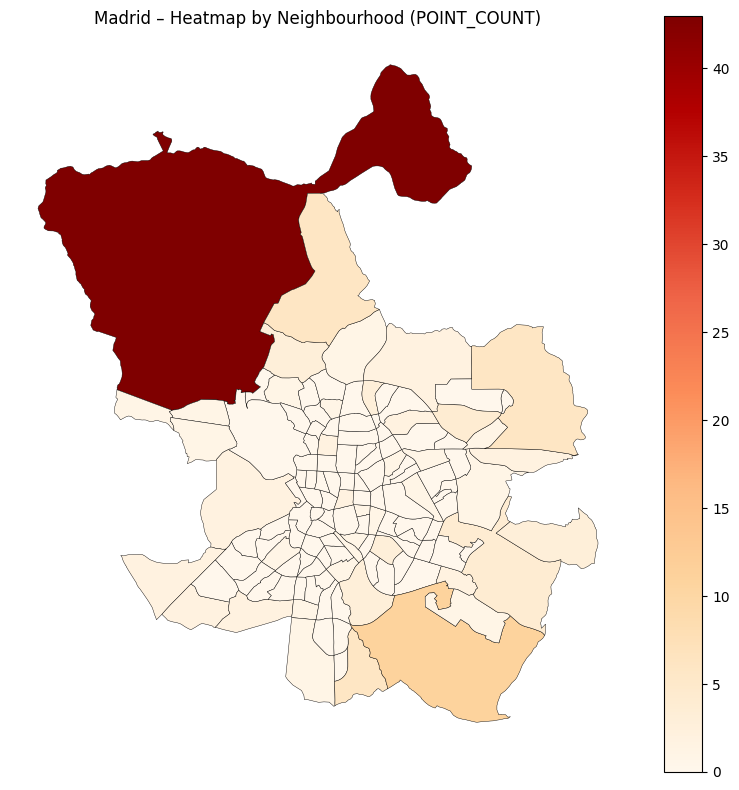

In [35]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Aggregate point counts per barrio
barrio_counts = (
    df_final
    .groupby("BARRIO")
    .size()
    .reset_index(name="POINT_COUNT")
)

barrio_counts.head()

# 2) Reload barrios polygons (if not already in memory)
barrios_shp_path = Path("neighborhoods/BARRIOS.shp")
gdf_barrios = gpd.read_file(barrios_shp_path)
gdf_barrios = gdf_barrios.to_crs(epsg=4326)

# Column in shapefile with barrio name
BARRIO_NAME_COL = "NOMBRE"

# 3) Join polygons with counts
gdf_barrios_counts = gdf_barrios.merge(
    barrio_counts,
    left_on=BARRIO_NAME_COL,
    right_on="BARRIO",
    how="left"
)

# Replace NaN with 0 for polygons without points
gdf_barrios_counts["POINT_COUNT"] = gdf_barrios_counts["POINT_COUNT"].fillna(0)

# 4) Plot choropleth
fig, ax = plt.subplots(figsize=(8, 8))

gdf_barrios_counts.plot(
    column="POINT_COUNT",
    ax=ax,
    legend=True,
    cmap="OrRd",  # red-ish heatmap
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("Madrid – Heatmap by Neighbourhood (POINT_COUNT)")
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 12. Hexagonal H3 heatmap over Madrid

To highlight the H3 side of the story, we can build a **hexagonal grid heatmap**:

1. Aggregate all Madrid points by their H3 index at resolution 6 (`H3_R6`).
2. Convert each H3 cell into a polygon (hexagon) using the H3 library.
3. Build a GeoDataFrame of hexagons with `POINT_COUNT` as an attribute.
4. Plot the hexagons coloured by `POINT_COUNT`.

This clearly shows:

- How H3 partitions the city into a regular hexagonal grid.
- How density varies across hexagons instead of administrative boundaries.


In [36]:
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import h3

# Helper: H3 index -> list of (lat, lon) vertices (version-safe)
def h3_to_boundary(h3_index: str):
    """
    Convert an H3 index to a list of (lat, lon) vertices.

    Compatible with different h3-python versions.
    """
    # Classic API
    if hasattr(h3, "h3_to_geo_boundary"):
        return h3.h3_to_geo_boundary(h3_index)
    # Newer API (v4)
    if hasattr(h3, "cell_to_boundary"):
        return h3.cell_to_boundary(h3_index)
    # Fallback via submodule
    try:
        from h3 import h3 as h3core
        if hasattr(h3core, "h3_to_geo_boundary"):
            return h3core.h3_to_geo_boundary(h3_index)
    except Exception:
        pass

    raise AttributeError(
        "Could not find a suitable H3 boundary function. "
        f"Available attributes in h3: {dir(h3)}"
    )

# 1) Aggregate by H3_R6
WORKING_RES = 6
h3_col = f"H3_R{WORKING_RES}"

agg_h3 = (
    df_final
    .groupby(h3_col)
    .size()
    .reset_index(name="POINT_COUNT")
    .rename(columns={h3_col: "H3_INDEX"})
)

agg_h3.head()

# 2) Convert each H3 cell to a shapely Polygon
polygons = []
for h in agg_h3["H3_INDEX"]:
    boundary = h3_to_boundary(h)  # list of (lat, lon)
    # Convert to (lon, lat) for shapely
    boundary_lonlat = [(lon, lat) for lat, lon in boundary]
    poly = Polygon(boundary_lonlat)
    polygons.append(poly)

# 3) Build GeoDataFrame of hexagons
gdf_hex = gpd.GeoDataFrame(
    agg_h3.copy(),
    geometry=polygons,
    crs="EPSG:4326"
)

gdf_hex.head()


,H3_INDEX,POINT_COUNT,geometry
0,86390ca07ffffff,10,"POLYGON ((-3.61181 40.40697, -3.65210 40.39440..."
1,86390ca0fffffff,4,"POLYGON ((-3.53705 40.39764, -3.57733 40.38510..."
2,86390ca17ffffff,5,"POLYGON ((-3.65788 40.35996, -3.69816 40.34737..."
3,86390ca1fffffff,3,"POLYGON ((-3.58313 40.35067, -3.62339 40.33811..."
4,86390ca27ffffff,10,"POLYGON ((-3.64053 40.46326, -3.68086 40.45070..."


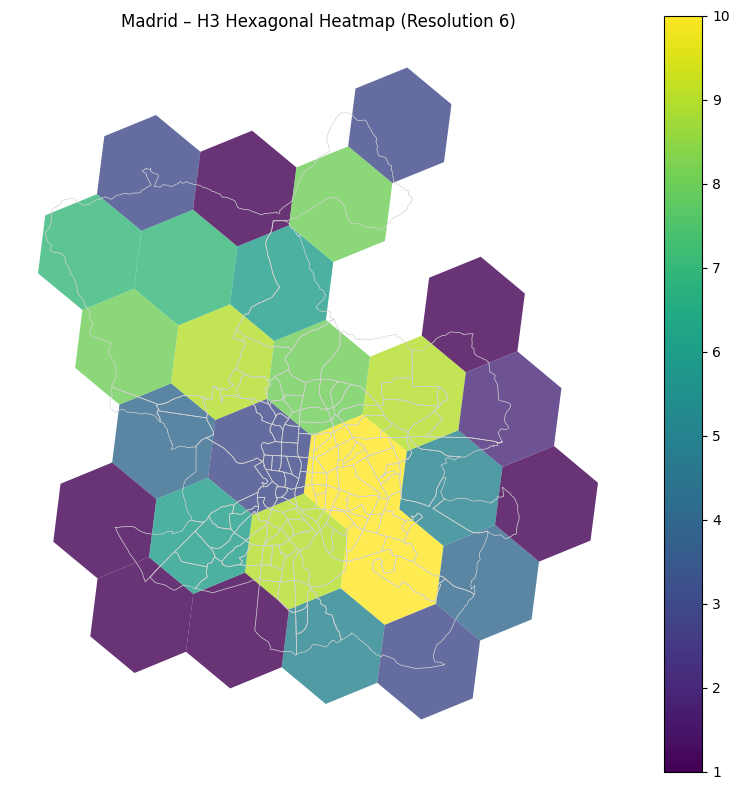

In [37]:
fig, ax = plt.subplots(figsize=(8, 8))

# Optionally, draw barrio outlines in grey as context
gdf_barrios.boundary.plot(ax=ax, color="lightgrey", linewidth=0.5)

# Plot H3 hexagons coloured by POINT_COUNT
gdf_hex.plot(
    column="POINT_COUNT",
    ax=ax,
    legend=True,
    cmap="viridis",  # hex heatmap
    edgecolor="none",
    alpha=0.8,
)

ax.set_title(f"Madrid – H3 Hexagonal Heatmap (Resolution {WORKING_RES})")
ax.set_axis_off()

plt.tight_layout()
plt.show()
